# $H_1$ 

The `logi_full` model is used to accept the lower 80% default prediction of the test set. Given this condition, the firm has a bad rate of 5.76328%. Your task is to propose a different model or models to reduce the current bad rate, subject to an acceptance rate of 80%. Your report should include: (1) a brief explanation of the problem; (2) a brief explanation of your proposed solution to the problem; (3) a clear comparison of the current bad rate and the estimated bad rate of your proposed solution, including a demonstration that your proposed solution meets the constraint of having an acceptance rate of 80%, and including tables and plots to support your answer; and (4) a brief conclusion.

# Index:
## 1. Introduction and Setup
  	1.1 Problem Definition
  		1.1.1 How will we solve it?
 	1.2 Setup and Libraries
## 2. Preparing the Data
	2.1 Data Loading
	2.2 Renaming Columns
 	2.3 Data Inspection
 	2.4 Cross-Tabulation of Key Variables
 	2.5 Analysis of Income Distribution
 	2.6 Identification of High-Income Individuals
 	2.7 Removing High-Income Individuals
	2.8 Updated Boxplot of Annual Income
## 3. Preparing Training and Test Sets
	3.1 Proportions of Loan Status
	3.2 Preview of Training Set
## 4. Building Logistic Regression Models
	4.1 Model All
	4.2 Model Topz
## 5. Decision Tree Model
	5.1 Model Complexity Parameter (CP) Analysis
## 6. Prediction and Model Evaluation
	6.1 Prediction of the Loan Status
	6.2 Comparison Plot
	6.3 Cutoff Definition
	6.4 Default Filtering
	6.5 Cutoff Definition for Model Topz
	6.6 Evaluation of Performance
## 7. Bad Rate Calculation
	7.1 Tree Model
	7.2 Logistic Model
	7.3 Acceptance Tables
## 8. Conclusions

# **1. Introduction and Setup**

### 1.1 Problem Definition 

In this project, our goal is to develop a model that reduces the bad rate of loan defaults below the current rate of 5.76328% while maintaining a loan acceptance rate of 80%. Achieving this requires a careful balance between minimizing the risk of defaults and ensuring a high level of loan approvals. 

### 1.1.1 How will we solve it?

We will explore various predictive models, one of which is a decision tree model, in order to select the most suitable ones and fine-tune them based on key performance metrics to optimize both the bad rate and acceptance rate.

### 1.2 Setup and Libraries

We begin by setting up our environment, ensuring that all necessary libraries are installed and loaded. These libraries will allow us to manipulate data, perform advanced statistical analysis, and visualize our results. For instance, **gmodels** is used for cross-tabulation, **pROC** for ROC curve analysis, and **rpart** for decision tree modeling.

By ensuring that these libraries are properly installed and loaded, we set up a robust environment for our analysis and modeling work.

In [ ]:
getwd()
list.files()

In [1]:
# Libraries

# Install the gmodels package if it is not already installed
if (!requireNamespace("gmodels", quietly = TRUE)) {
  install.packages("gmodels")
}

# Install the pROC package if it is not already installed
if (!requireNamespace("pROC", quietly = TRUE)) {
  install.packages("pROC")
}

# Install the rpart package if it is not already installed
if (!requireNamespace("rpart", quietly = TRUE)) {
  install.packages("rpart")
}

library(gmodels) # CrossTable()
library(ggplot2) # high-quality plots
library(tidyr) # gather()
library(dplyr) # filtering, selecting, and mutating data frames
library(pROC) # roc
library(rpart) # building decision tree models
library(rpart.plot) # making the models easier to interpret

# Downloading packages -------------------------------------------------------
- Downloading gmodels from CRAN ...             OK [114.4 Kb in 0.19s]
- Downloading gdata from CRAN ...               OK [490.9 Kb in 0.2s]
- Downloading gtools from CRAN ...              OK [352.8 Kb in 0.19s]
Successfully downloaded 3 packages in 1.7 seconds.

The following package(s) will be installed:
- gdata   [3.0.0]
- gmodels [2.19.1]
- gtools  [3.9.5]
These packages will be installed into "~/renv/library/linux-ubuntu-jammy/R-4.4/x86_64-pc-linux-gnu".

# Installing packages --------------------------------------------------------
- Installing gtools ...                         OK [installed binary and cached in 0.64s]
- Installing gdata ...                          OK [installed binary and cached in 0.77s]
- Installing gmodels ...                        OK [installed binary and cached in 0.69s]



Attaching package: ‘dplyr’


The following objects are masked from ‘package:stats’:

    filter, lag


The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union


Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following object is masked from ‘package:gmodels’:

    ci


The following objects are masked from ‘package:stats’:

    cov, smooth, var




# 2. Preparing the Data


To begin our analysis, we first need to prepare and clean our data. This involves loading the dataset and examining its structure to understand its contents and ensure that it is ready for further analysis.

### 2.1 Data Loading


Our dataset is loaded from the CSV file named loan_data_ARF.csv using the read.csv() function. This function helped us read the data into a data frame called dat. We then used the str() function to display the structure of the dataset. This step focuses on understanding the data's composition, identifying any potential issues with data types, and preparing the data for analysis.

In [27]:
dat <- read.csv("loan_data_ARF.csv")
str(dat)

'data.frame':	29092 obs. of  10 variables:
 $ loan_status   : int  0 0 0 0 0 0 1 0 1 0 ...
 $ loan_amnt     : int  5000 2400 10000 5000 3000 12000 9000 3000 10000 1000 ...
 $ int_rate      : num  10.7 11 13.5 11 11 ...
 $ grade         : chr  "B" "C" "C" "A" ...
 $ emp_length    : int  10 25 13 3 9 11 0 3 3 0 ...
 $ home_ownership: chr  "RENT" "RENT" "RENT" "RENT" ...
 $ annual_inc    : num  24000 12252 49200 36000 48000 ...
 $ age           : int  33 31 24 39 24 28 22 22 28 22 ...
 $ sex           : int  0 0 0 0 1 1 1 1 0 1 ...
 $ region        : chr  "E" "E" "S" "S" ...


### 2.2 Renaming Columns

To make the dataset more manageable, we renamed certain columns to use more descriptive and concise labels. This step was implemented to enhance clarity and ease of reference.

In [28]:
old_names <- colnames(dat)
colnames(dat) <- c("l_status", "l_amnt", "int", "grade", "emp_len", 
                   "home", "income", "age", "sex", "region")
data.frame(old_names, "new_names" = colnames(dat))
#Solo se cambio loan_st a l_status

old_names,new_names
<chr>,<chr>
loan_status,l_status
loan_amnt,l_amnt
int_rate,int
grade,grade
emp_length,emp_len
home_ownership,home
annual_inc,income
age,age
sex,sex


### 2.3 Data Inspection


We used the head() function to display the first 10 rows of the dataset. This allowed us to quickly review a sample of the data, ensuring that it has been loaded correctly. 

Next, we used the CrossTable() function from the gmodels package to perform a cross-tabulation of the home variable. This provides a summary of the distribution of values within the home column, helping us understand the frequency and proportion of each category.

In [29]:
head(dat, 10)
CrossTable(dat$home)

,l_status,l_amnt,int,grade,emp_len,home,income,age,sex,region
,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<dbl>,<int>,<int>,<chr>
1,0,5000,10.65,B,10,RENT,24000,33,0,E
2,0,2400,10.99,C,25,RENT,12252,31,0,E
3,0,10000,13.49,C,13,RENT,49200,24,0,S
4,0,5000,10.99,A,3,RENT,36000,39,0,S
5,0,3000,10.99,E,9,RENT,48000,24,1,N
6,0,12000,12.69,B,11,OWN,75000,28,1,N
7,1,9000,13.49,C,0,RENT,30000,22,1,N
8,0,3000,9.91,B,3,RENT,15000,22,1,N
9,1,10000,10.65,B,3,RENT,100000,28,0,W



 
   Cell Contents
|-------------------------|
|                       N |
|         N / Table Total |
|-------------------------|

 
Total Observations in Table:  29092 

 
          |  MORTGAGE |     OTHER |       OWN |      RENT | 
          |-----------|-----------|-----------|-----------|
          |     12002 |        97 |      2301 |     14692 | 
          |     0.413 |     0.003 |     0.079 |     0.505 | 
          |-----------|-----------|-----------|-----------|



 


### 2.4 Cross-Tabulation of Key Variables

To analyze the relationship between categorical variables in our dataset, we performed a cross-tabulation between the home and l_status variables.

We used the CrossTable() function from the gmodels package to perform this cross-tabulation. By focusing on row proportions, we assessed how the distribution of loan statuses (l_status) varied across different home ownership categories (home).

The cross-tabulation analysis revealed distinct patterns in default rates based on home ownership status, highlighting the importance of including home as a feature in the model. By focusing on these insights, we gained an understanding of the factors contributing to loan defaults.
 

In [30]:
CrossTable(dat$home, dat$l_status, prop.r = TRUE,
           prop.c = FALSE, prop.t = FALSE, prop.chisq = FALSE)


 
   Cell Contents
|-------------------------|
|                       N |
|           N / Row Total |
|-------------------------|

 
Total Observations in Table:  29092 

 
             | dat$l_status 
    dat$home |         0 |         1 | Row Total | 
-------------|-----------|-----------|-----------|
    MORTGAGE |     10821 |      1181 |     12002 | 
             |     0.902 |     0.098 |     0.413 | 
-------------|-----------|-----------|-----------|
       OTHER |        80 |        17 |        97 | 
             |     0.825 |     0.175 |     0.003 | 
-------------|-----------|-----------|-----------|
         OWN |      2049 |       252 |      2301 | 
             |     0.890 |     0.110 |     0.079 | 
-------------|-----------|-----------|-----------|
        RENT |     12915 |      1777 |     14692 | 
             |     0.879 |     0.121 |     0.505 | 
-------------|-----------|-----------|-----------|
Column Total |     25865 |      3227 |     29092 | 
-------------|-------

Here are the key findings: 

The variation in default rates across different home ownership statuses suggested that home is a significant variable that may help in predicting loan defaults.

These insights indicate us that incorporating home ownership status into predictive models could improve the accuracy of default predictions.


### 2.5 Analysis of Income Distribution

To explore the distribution of annual income in our dataset, we created a boxplot. This visualization helps to understand the spread and central tendency of income values, as well as to identify any potential outliers.

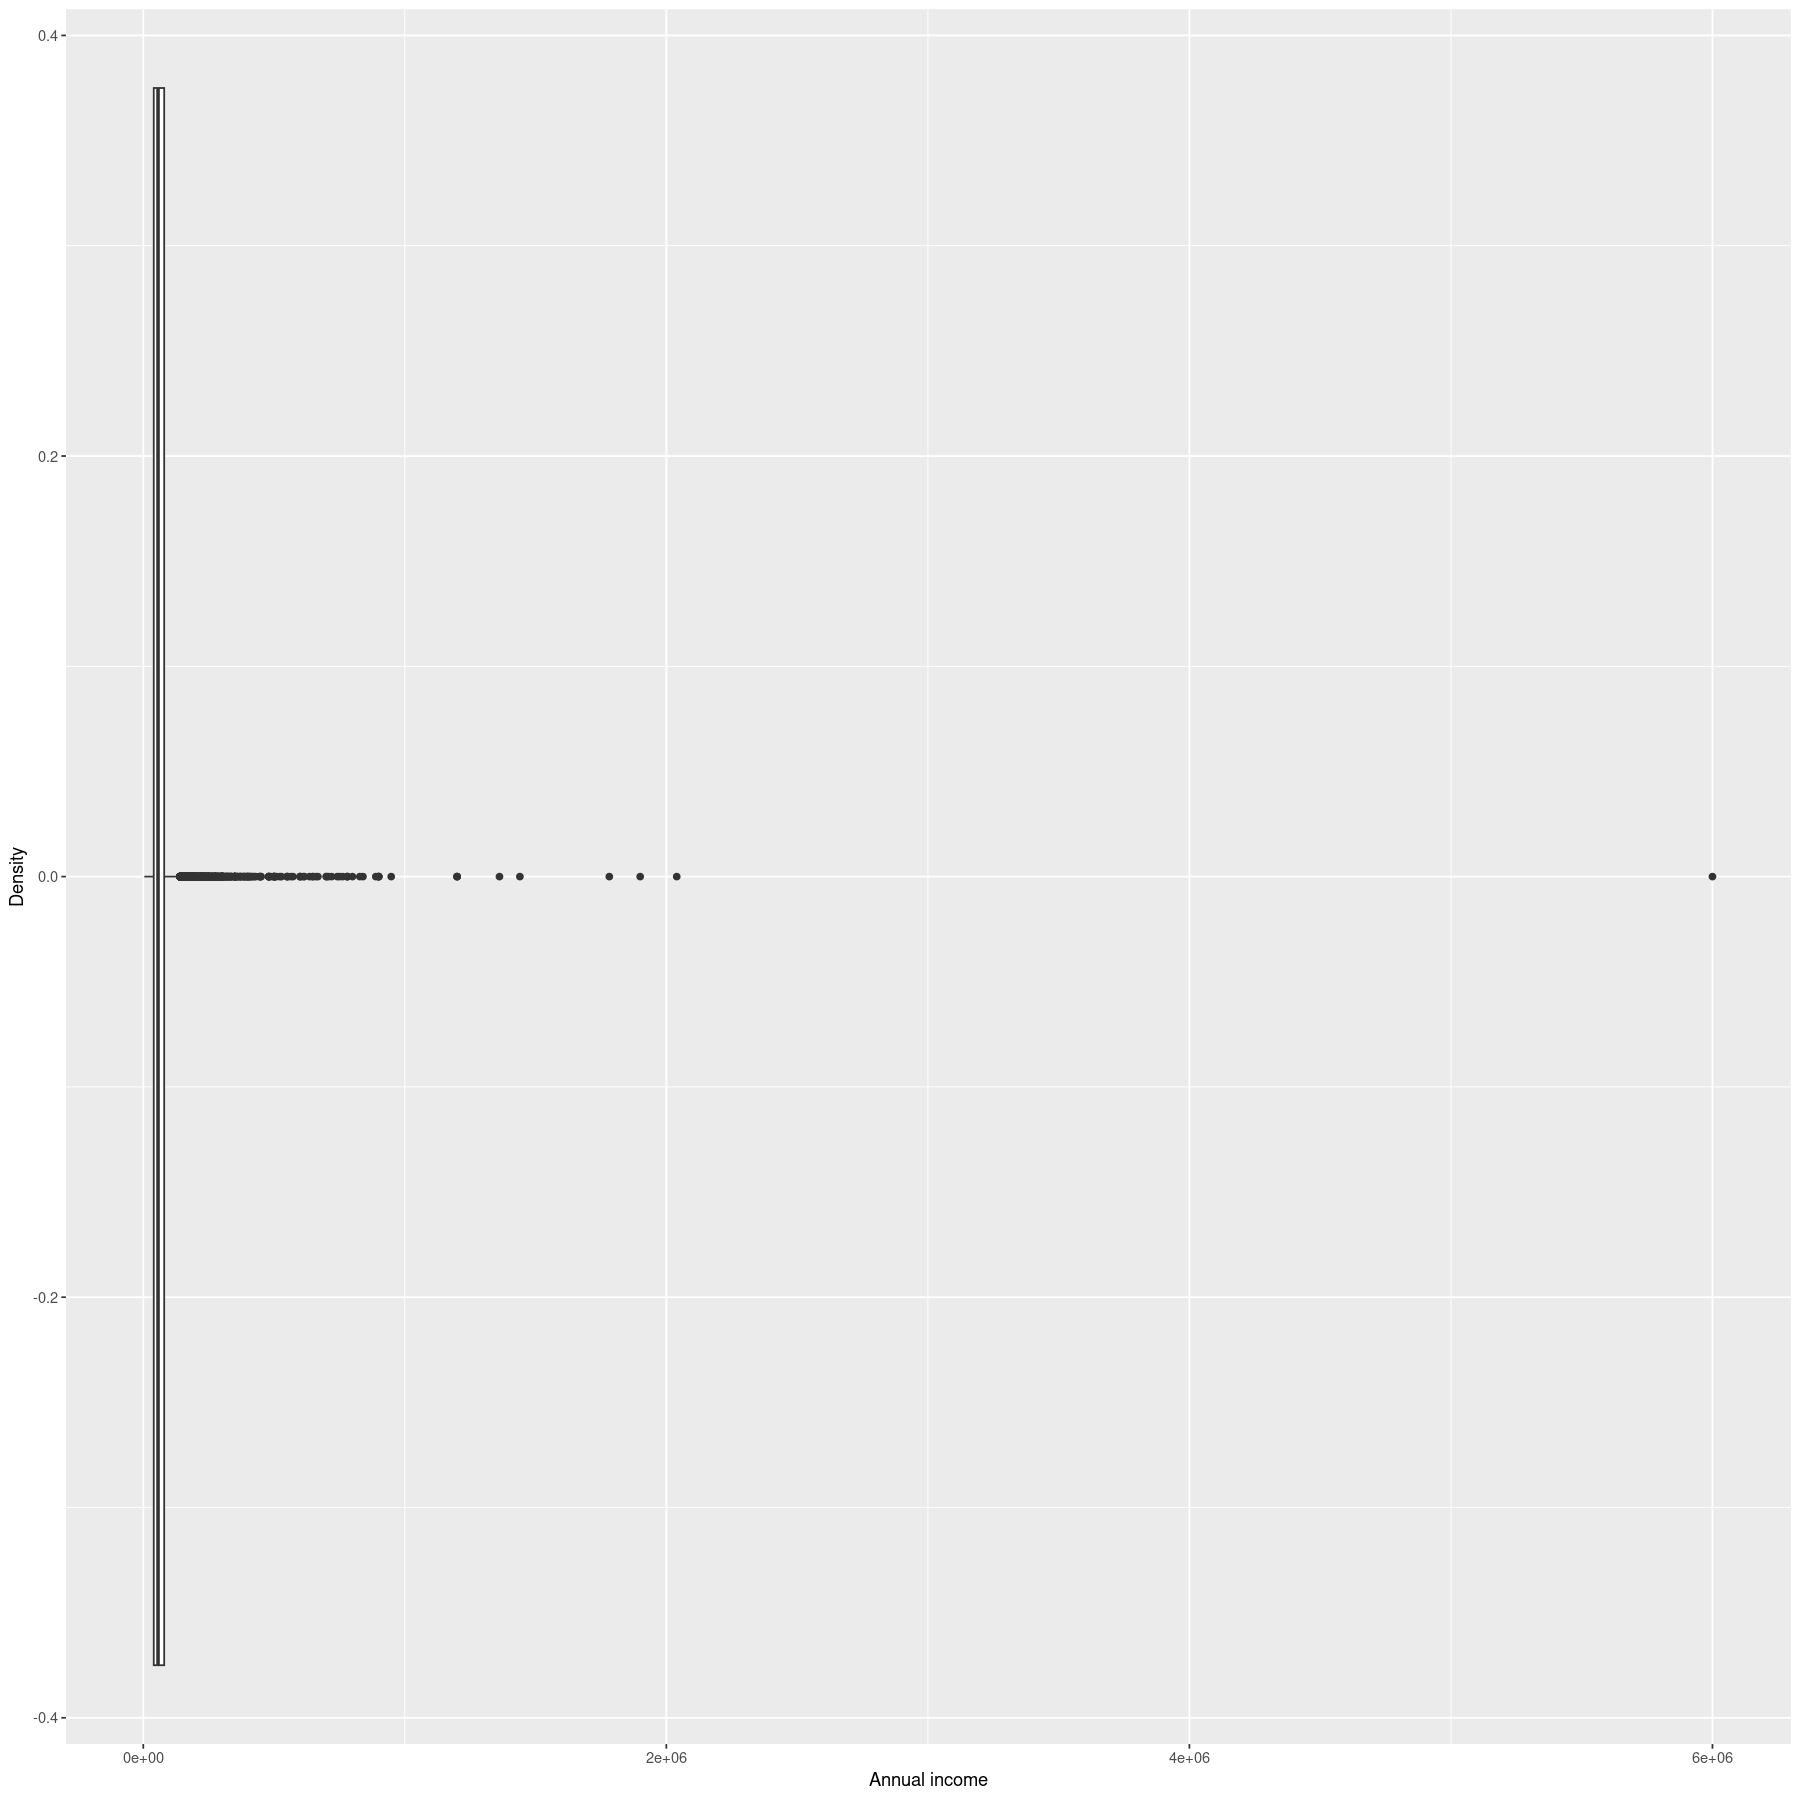

In [31]:
ggplot(dat, aes(income)) + 
  geom_boxplot() +
  labs(y = "Density",
       x = "Annual income") +
  theme(legend.position = "bottom", legend.title = element_blank())

From the plot, we observed that there is a very large value for annual income on the horizontal axis, reaching up to $6,000,000. Additionally, the data reveals that a small number of individuals have exceptionally high incomes.

### 2.6 Identification of High-Income Individuals

To better understand the subset of individuals with exceptionally high incomes, we filtered the dataset to include only those with an annual income exceeding $1,000,000.

Our analysis revealed an unusual case where one individual not only has an exceptionally high income, but is also listed as 144 years old. Given the improbability of this age, we decided to remove these 9 observations from the dataset.

In [32]:
high_income <- dat[(dat$income > 1000000), ]
high_income

,l_status,l_amnt,int,grade,emp_len,home,income,age,sex,region
,<int>,<int>,<dbl>,<chr>,<int>,<chr>,<dbl>,<int>,<int>,<chr>
4861,0,12025,14.27,C,13,RENT,1782000,63,0,E
13931,0,10000,6.54,A,16,OWN,1200000,36,0,W
15386,0,1500,10.99,A,5,MORTGAGE,1900000,60,1,N
16713,0,12000,7.51,A,1,MORTGAGE,1200000,32,0,E
19486,0,5000,12.73,C,12,MORTGAGE,6000000,144,1,E
22811,0,10000,10.99,A,1,MORTGAGE,1200000,40,1,E
23361,0,6400,7.40,A,7,MORTGAGE,1440000,44,1,E
23683,0,6600,7.74,A,9,MORTGAGE,1362000,47,0,E
28468,0,8450,12.29,C,0,RENT,2039784,42,0,E


### 2.7. Removing High-Income Individuals

To address the issue of individuals with exceptionally high incomes, we identified and removed these observations from our dataset.

In [33]:
high_income_index <- data.frame(value = as.integer(rownames(high_income)))
dat <- dat[-high_income_index$value,]

We created a data frame, **high_income_index,** containing the indices of the high-income individuals identified earlier. We used this data frame to remove the corresponding rows from the main dataset dat. This allows our dataset reflect the typical income distribution in a more accurate manner.

### 2.8 Updated Boxplot of Annual Income

To visualize the distribution of annual income after removing the outliers, we generated a new boxplot.

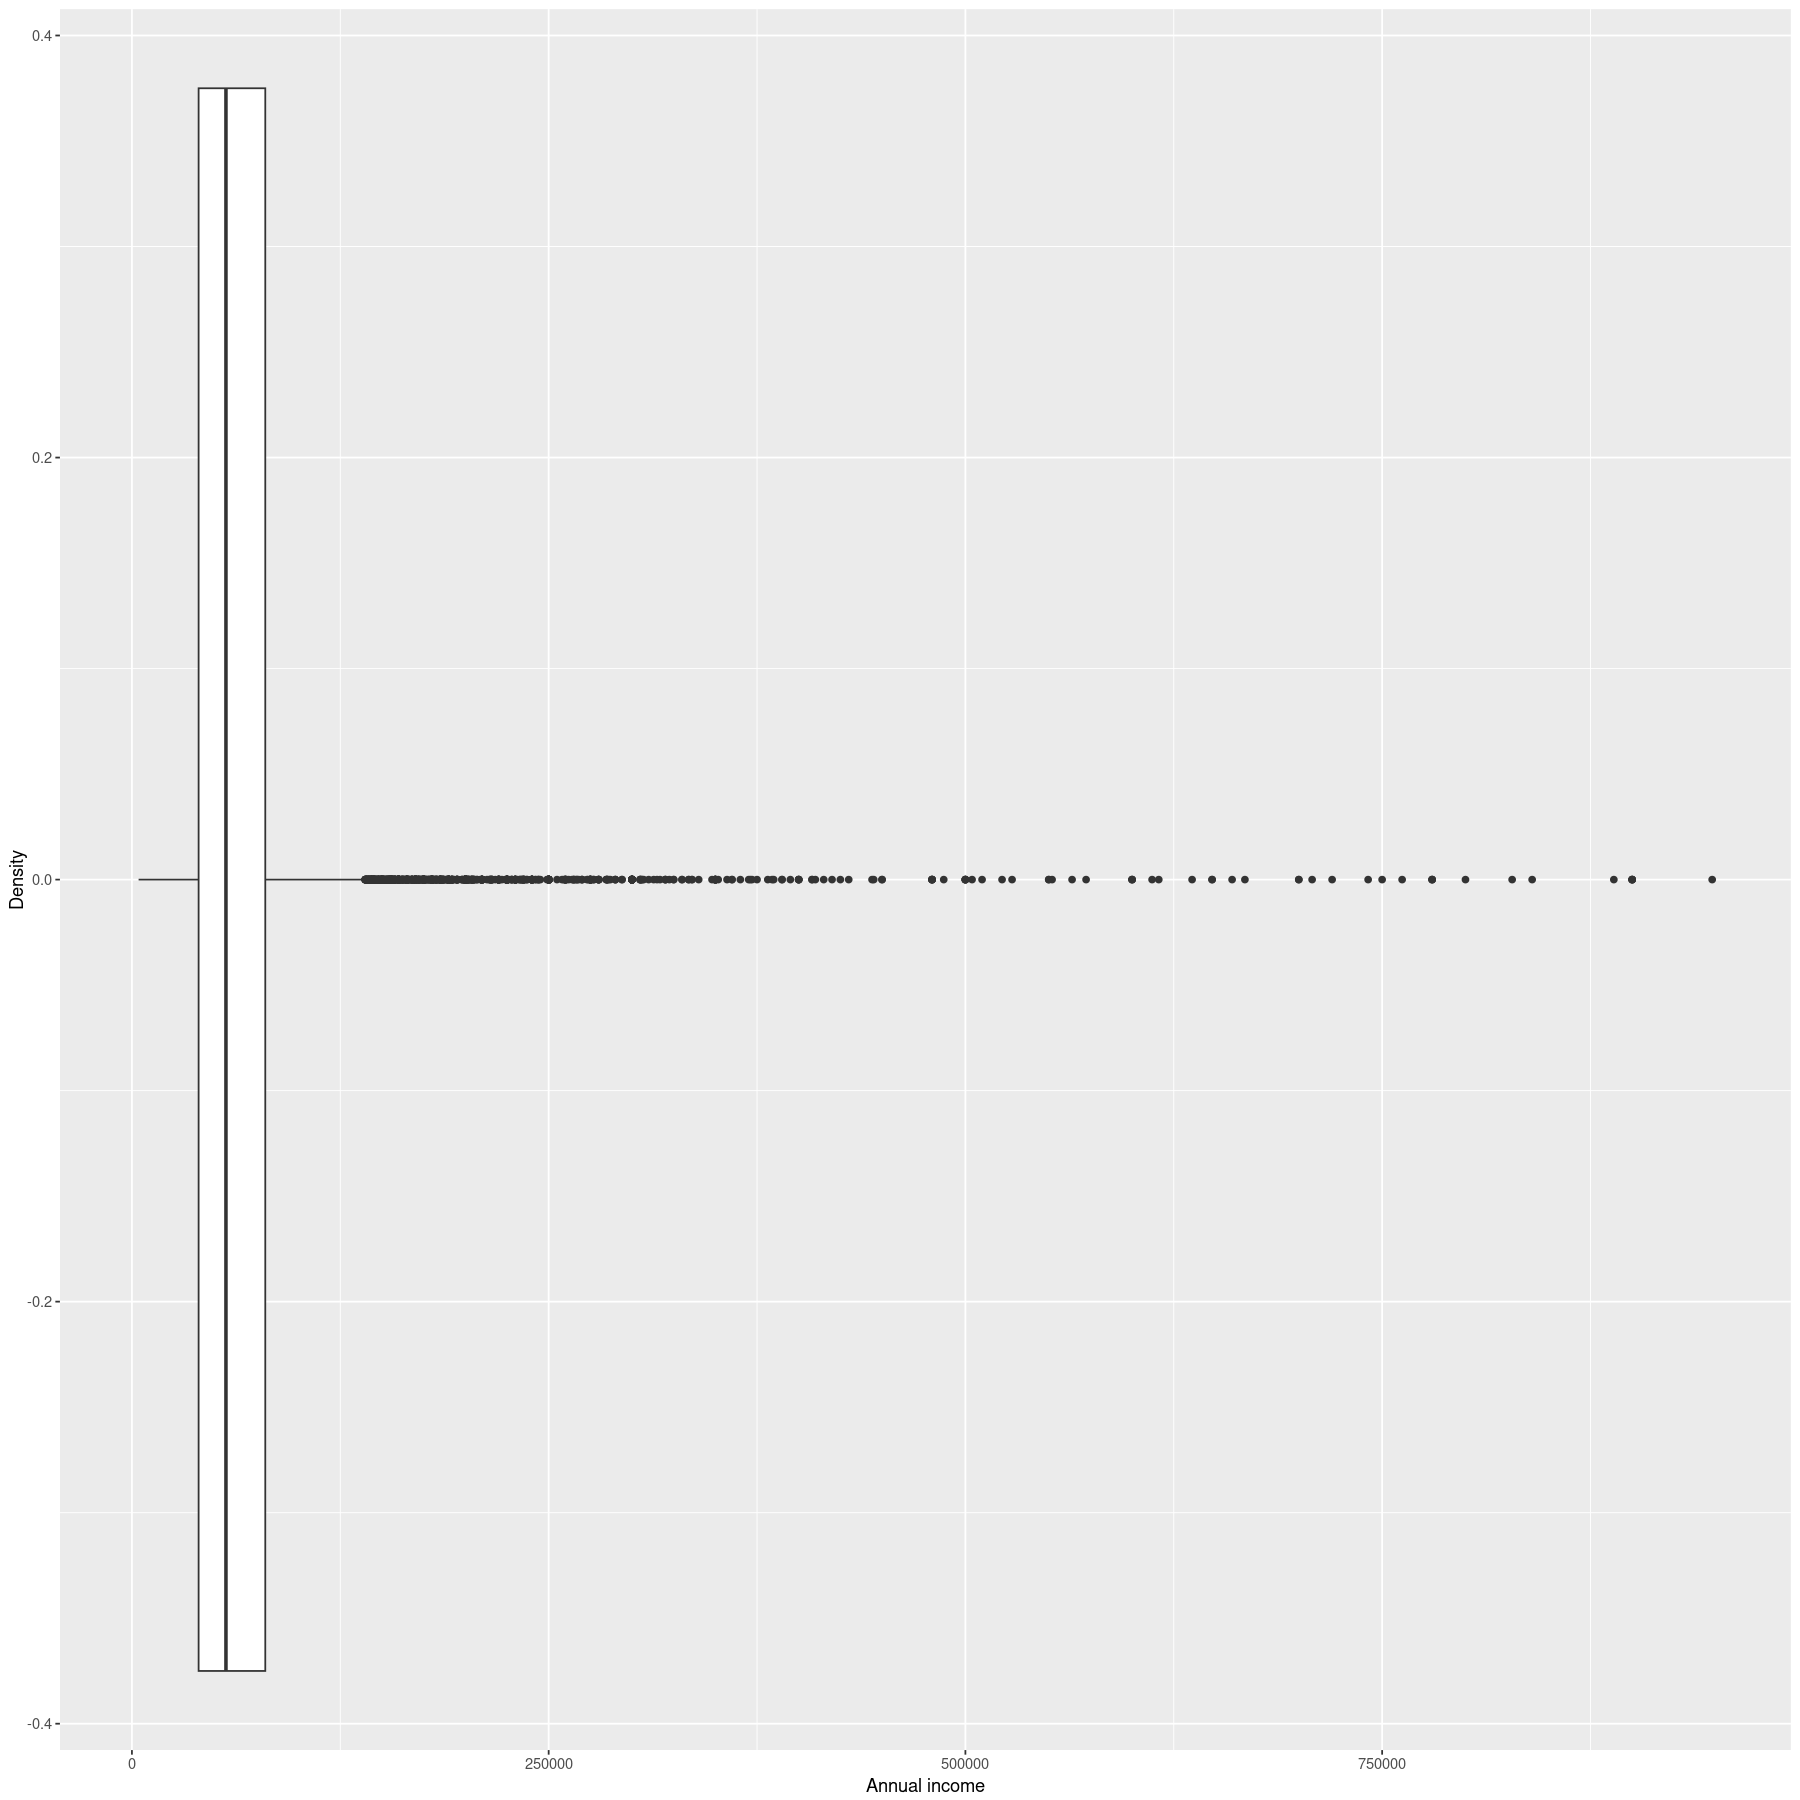

In [34]:
ggplot(dat, aes(income)) + 
  geom_boxplot() +
  labs(y = "Density", x = "Annual income") +
  theme(legend.position = "bottom", legend.title = element_blank())

The boxplot now shows a more refined distribution of income values, highlighting the median, quartiles, and range without the influence of extreme values. 

# 3. Preparing Training and Test Sets

To prepare for model development, we converted the loan status variable to a factor and then split the dataset into training and test sets.

In [35]:
# It is convenient to set the loan status as factor.
dat$l_status <- as.factor(dat$l_status)
set.seed(567)
index_train <- cbind(runif(1 : nrow(dat), 0 , 1), c(1 : nrow(dat)))
index_train <- order(index_train[, 1])
index_train <- index_train[1: (2/3 * nrow(dat))]
# Create training set
train <- dat[index_train, ]
# Create test set
test <- dat[-index_train, ]

We first set the l_status variable as a **factor** to ensure that it is treated as a categorical variable in the models. We then set a random seed for reproducibility and created a random index to split the dataset into training and test sets. 

Two-thirds of the data was allocated to the training set, while the remaining one-third was used as the test set. This split allows us to train our models and evaluate their performance on an independent subset.

### 3.1 Proportions of Loan Status 

To analyze the distribution of loan statuses across the entire dataset, training set, and test set, we calculated the proportions of each status category.

In [36]:
# Calculate proportions of loan status in the full dataset
dat_prop <- table(dat$l_status)/sum(table(dat$l_status))
# Calculate proportions of loan status in the training set
train_prop <- table(train$l_status)/sum(table(train$l_status))
# Calculate proportions of loan status in the test set
test_prop <- table(test$l_status)/sum(table(test$l_status))
# Combine proportions into a single data frame
prop <- data.frame(rbind(dat_prop, train_prop, test_prop))
colnames(prop) <- c("no defaults", "defaults")
prop

,no defaults,defaults
,<dbl>,<dbl>
dat_prop,0.8890417,0.1109583
train_prop,0.8882298,0.1117702
test_prop,0.8906653,0.1093347


We determined the proportions of each loan status (no defaults and defaults) for the full dataset, training set, and test set. 

This was done by first calculating the counts of each status, then dividing by the total number of observations in each respective dataset. The results were combined into a data frame for easy comparison.

The results indicate that the distribution of loan statuses is **consistent across the full dataset, training set, and test set**. We aimed to achieve this consistency because it ensures that the models trained on the training set will be evaluated on a test set that accurately reflects the overall data distribution

### 3.2 Preview of Training Set

To examine the first few entries of the training dataset, we used the head() function.

In [37]:
head(train)

,l_status,l_amnt,int,grade,emp_len,home,income,age,sex,region
,<fct>,<int>,<dbl>,<chr>,<int>,<chr>,<dbl>,<int>,<int>,<chr>
21547,0,4000,10.25,B,6,RENT,26000,27,1,N
22625,0,5000,14.26,C,3,RENT,280000,36,1,N
20340,0,18000,18.30,F,10,RENT,121000,24,1,N
1911,0,5600,7.90,A,3,RENT,32000,22,0,W
4021,0,2700,14.27,C,5,MORTGAGE,88500,32,1,N
16887,0,15000,10.38,B,10,MORTGAGE,75000,23,0,W


The head() function displayed the first six rows of the training set, showing key variables such as l_status (loan status), l_amnt (loan amount), int (interest rate), grade (loan grade), emp_len (employment length), home (home ownership status), income, age, sex, and region. 

This preview allowed us to confirm that the data has been correctly split and provided a view of the variables that will be used in model training.



# 4. Building Logistic Regression Models

In this section, we focused on building comprehensive logistic regression models using all available variables to predict loan defaults. This approach allowed us to analyze the combined effects of all predictors on the risk of default and to identify key factors influencing loan performance.

### 4.1 Model All

First we developed a logistic regression model using all available variables in the training set.


In [38]:
# Model All 
model_all <- glm(l_status ~ age + int + grade + log(l_amnt) + 
                  log(income) + emp_len + home + sex + region , family = "binomial", data = train)
summary(model_all)


Call:
glm(formula = l_status ~ age + int + grade + log(l_amnt) + log(income) + 
    emp_len + home + sex + region, family = "binomial", data = train)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.399e+01  1.263e+02  -0.111   0.9118    
age         -4.921e-04  4.093e-03  -0.120   0.9043    
int          2.998e-02  1.871e-02   1.602   0.1092    
gradeB       5.402e-01  9.325e-02   5.793 6.90e-09 ***
gradeC       8.025e-01  1.267e-01   6.335 2.37e-10 ***
gradeD       1.073e+00  1.594e-01   6.731 1.69e-11 ***
gradeE       1.133e+00  2.078e-01   5.453 4.95e-08 ***
gradeF       1.703e+00  2.865e-01   5.944 2.77e-09 ***
gradeG       2.481e+00  4.979e-01   4.982 6.28e-07 ***
log(l_amnt)  1.400e-02  3.870e-02   0.362   0.7174    
log(income) -5.176e-01  5.316e-02  -9.736  < 2e-16 ***
emp_len      1.179e-02  3.850e-03   3.062   0.0022 ** 
homeOTHER   -4.564e-02  4.520e-01  -0.101   0.9196    
homeOWN     -4.834e-02  1.002e-01  -0.482   0.6295    
homeRENT 

In this step, we built a logistic regression model (model_all) incorporating all the available predictor variables from the training set. 

From this, we learned that loan grades are significant predictors of defaults, with higher grades (B through G) strongly associated with increased default probabilities. In contrast, higher income levels, as indicated by the log of income, are linked to a decreased likelihood of default. 

On the other hand, variables such as age, interest rate, home ownership status, sex, and region did not show significant impacts on default rates in this model. These results suggested that focusing on loan grades and income could improve the predictive accuracy for loan defaults.

### 4.2 Model Topz

For this model, we employed the stepwise selection method to refine our logistic regression model. This approach involved starting with a comprehensive model that included all candidate variables and then iteratively removing or adding variables based on their statistical significance to optimize the model. 

In [39]:
# Model Topz
model_topz <- step(glm(l_status ~ age + int  + grade + log(l_amnt) + 
                                log(income) + emp_len + income + home + int + region 									+ sex, 
                                family = "binomial", data = train))
 
#model_topz <- glm(l_status ~ I(int * 2) + grade + log(l_amnt) + 
#                                log(income) + emp_len  + region + age, 
#                                family = "binomial", data = train)
summary(model_topz)

Start:  AIC=10762.15
l_status ~ age + int + grade + log(l_amnt) + log(income) + emp_len + 
    income + home + int + region + sex

              Df Deviance   AIC
- home         3    10723 10757
- age          1    10722 10760
- log(l_amnt)  1    10722 10760
<none>              10722 10762
- int          1    10725 10763
- income       1    10726 10764
- emp_len      1    10732 10770
- grade        6    10777 10805
- log(income)  1    10772 10810
- sex          1    11282 11320
- region       3    12528 12562

Step:  AIC=10756.7
l_status ~ age + int + grade + log(l_amnt) + log(income) + emp_len + 
    income + region + sex

              Df Deviance   AIC
- age          1    10723 10755
- log(l_amnt)  1    10723 10755
<none>              10723 10757
- int          1    10725 10757
- income       1    10726 10758
- emp_len      1    10732 10764
- grade        6    10778 10800
- log(income)  1    10774 10806
- sex          1    11282 11314
- region       3    12529 12557

Step:  AIC=1075


Call:
glm(formula = l_status ~ int + grade + log(income) + emp_len + 
    income + region + sex, family = "binomial", data = train)

Coefficients:
              Estimate Std. Error z value Pr(>|z|)    
(Intercept) -1.279e+01  1.262e+02  -0.101  0.91929    
int          2.957e-02  1.871e-02   1.580  0.11411    
gradeB       5.420e-01  9.303e-02   5.827 5.66e-09 ***
gradeC       8.071e-01  1.265e-01   6.380 1.77e-10 ***
gradeD       1.078e+00  1.591e-01   6.775 1.24e-11 ***
gradeE       1.144e+00  2.072e-01   5.522 3.36e-08 ***
gradeF       1.702e+00  2.857e-01   5.958 2.55e-09 ***
gradeG       2.486e+00  4.984e-01   4.989 6.06e-07 ***
log(income) -6.272e-01  7.740e-02  -8.104 5.30e-16 ***
emp_len      1.178e-02  3.804e-03   3.097  0.00196 ** 
income       1.786e-06  9.374e-07   1.905  0.05680 .  
regionN     -1.723e+00  8.719e-02 -19.767  < 2e-16 ***
regionS      1.788e+01  1.262e+02   0.142  0.88738    
regionW      1.675e+01  1.262e+02   0.133  0.89442    
sex          1.676e+01  1.2

This model indicates that loan grades (grade) and the logarithm of income (log(income)) are significant predictors of loan defaults. Higher grades are associated with increased default probabilities, while higher income levels reduce the likelihood of defaults. The variables emp_len, income, and region also contribute to the model, though their significance varies


The main difference between model_topz and model_all is that model_topz focuses on a refined subset of variables, simplifying the model and reducing the AIC to 10753. This optimized approach makes this model more interpretable and potentially less prone to overfitting, thereby improving overall model efficiency.









# 5. Decision Tree Model

In our effort to innovate and streamline the process, we decided to create a decision tree model. By applying this technique, we aimed to enhance the efficiency of our analysis and gain deeper insights. The decision tree was constructed with a specific focus on reducing misclassification, using a loss matrix to penalize false positives more heavily, and a very low complexity parameter (cp) to capture intricate patterns within the data. 

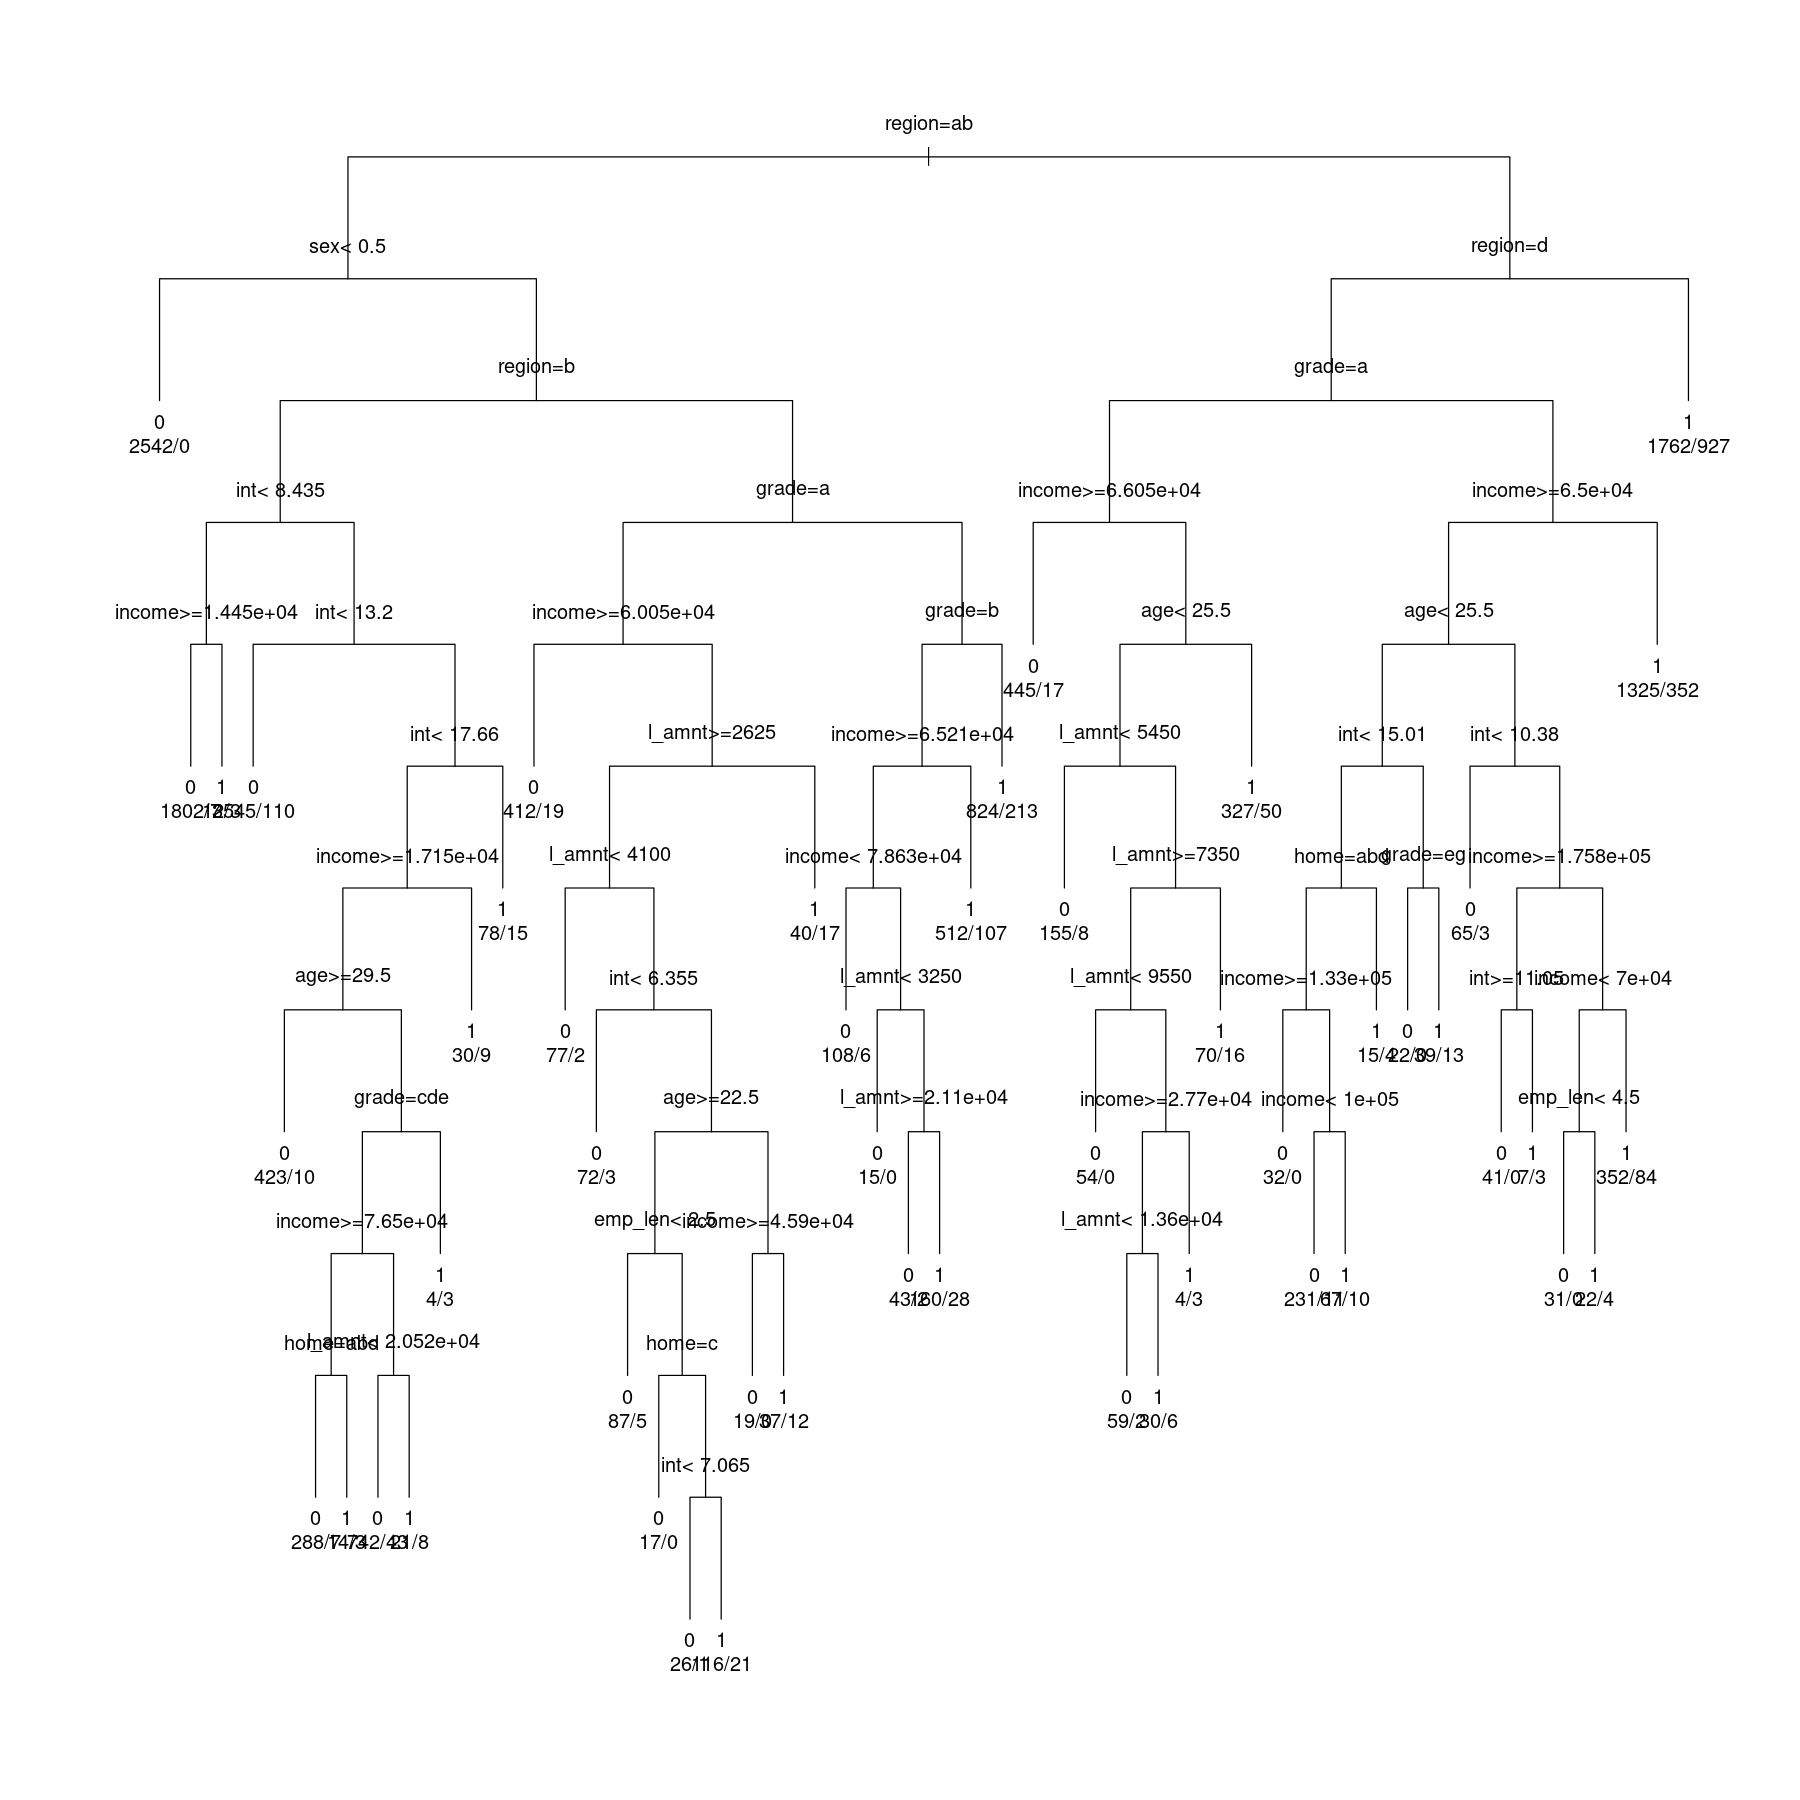

In [40]:
# Model Narnia

model_narnia_tree <- rpart(l_status ~ ., method = "class", data = train,
                           parms = list(loss = matrix(c(0, 10, 1, 0), ncol = 2)),
                           control = rpart.control(cp = 0.00085))
#summary(model_narnia_tree)
plot(model_narnia_tree, uniform = TRUE)
text(model_narnia_tree, use.n = TRUE)

As mentionated, the model was built with the rpart function, employing a loss matrix to penalize false positives more heavily, reflecting the higher cost of incorrect default predictions. We also set a very low complexity parameter (cp = 0.00085) to allow the tree to grow deeper and capture more detailed patterns in the data. 

The resulting tree was visualized with plot and text functions, which revealed the decision-making process and the splits used by the model. This approach aimed to add complexity to the model to better understand which variables and their interactions affect loan defaults. The results showed that, even though the model was more complex, it provided useful insights into important factors, offering a different view compared to simpler logistic regression models.

### 5.1 Model Complexity Parameter (CP) Analysis



We used the complexity parameter (CP) table and plot because they provide insights into the performance of the classification tree at various levels of complexity.


Classification tree:
rpart(formula = l_status ~ ., data = train, method = "class", 
    parms = list(loss = matrix(c(0, 10, 1, 0), ncol = 2)), control = rpart.control(cp = 0.00085))

Variables actually used in tree construction:
[1] age     emp_len grade   home    income  int     l_amnt  region  sex    

Root node error: 17221/19388 = 0.88823

n= 19388 

           CP nsplit rel error  xerror     xstd
1  0.32088729      0   1.00000 10.0000 0.025476
2  0.05211660      1   0.67911  3.0314 0.035588
3  0.00644562      3   0.57488  4.4956 0.039516
4  0.00532296      5   0.56199  4.1575 0.038914
5  0.00217757      8   0.54602  3.9559 0.038488
6  0.00214854     10   0.54166  3.8177 0.038148
7  0.00183884     11   0.53952  3.7861 0.038068
8  0.00165496     15   0.53197  3.7476 0.037968
9  0.00145172     18   0.52622  3.7320 0.037931
10 0.00139365     19   0.52477  3.6894 0.037817
11 0.00127751     23   0.51710  3.6753 0.037777
12 0.00123396     24   0.51582  3.6319 0.037655
13 0.00119041     

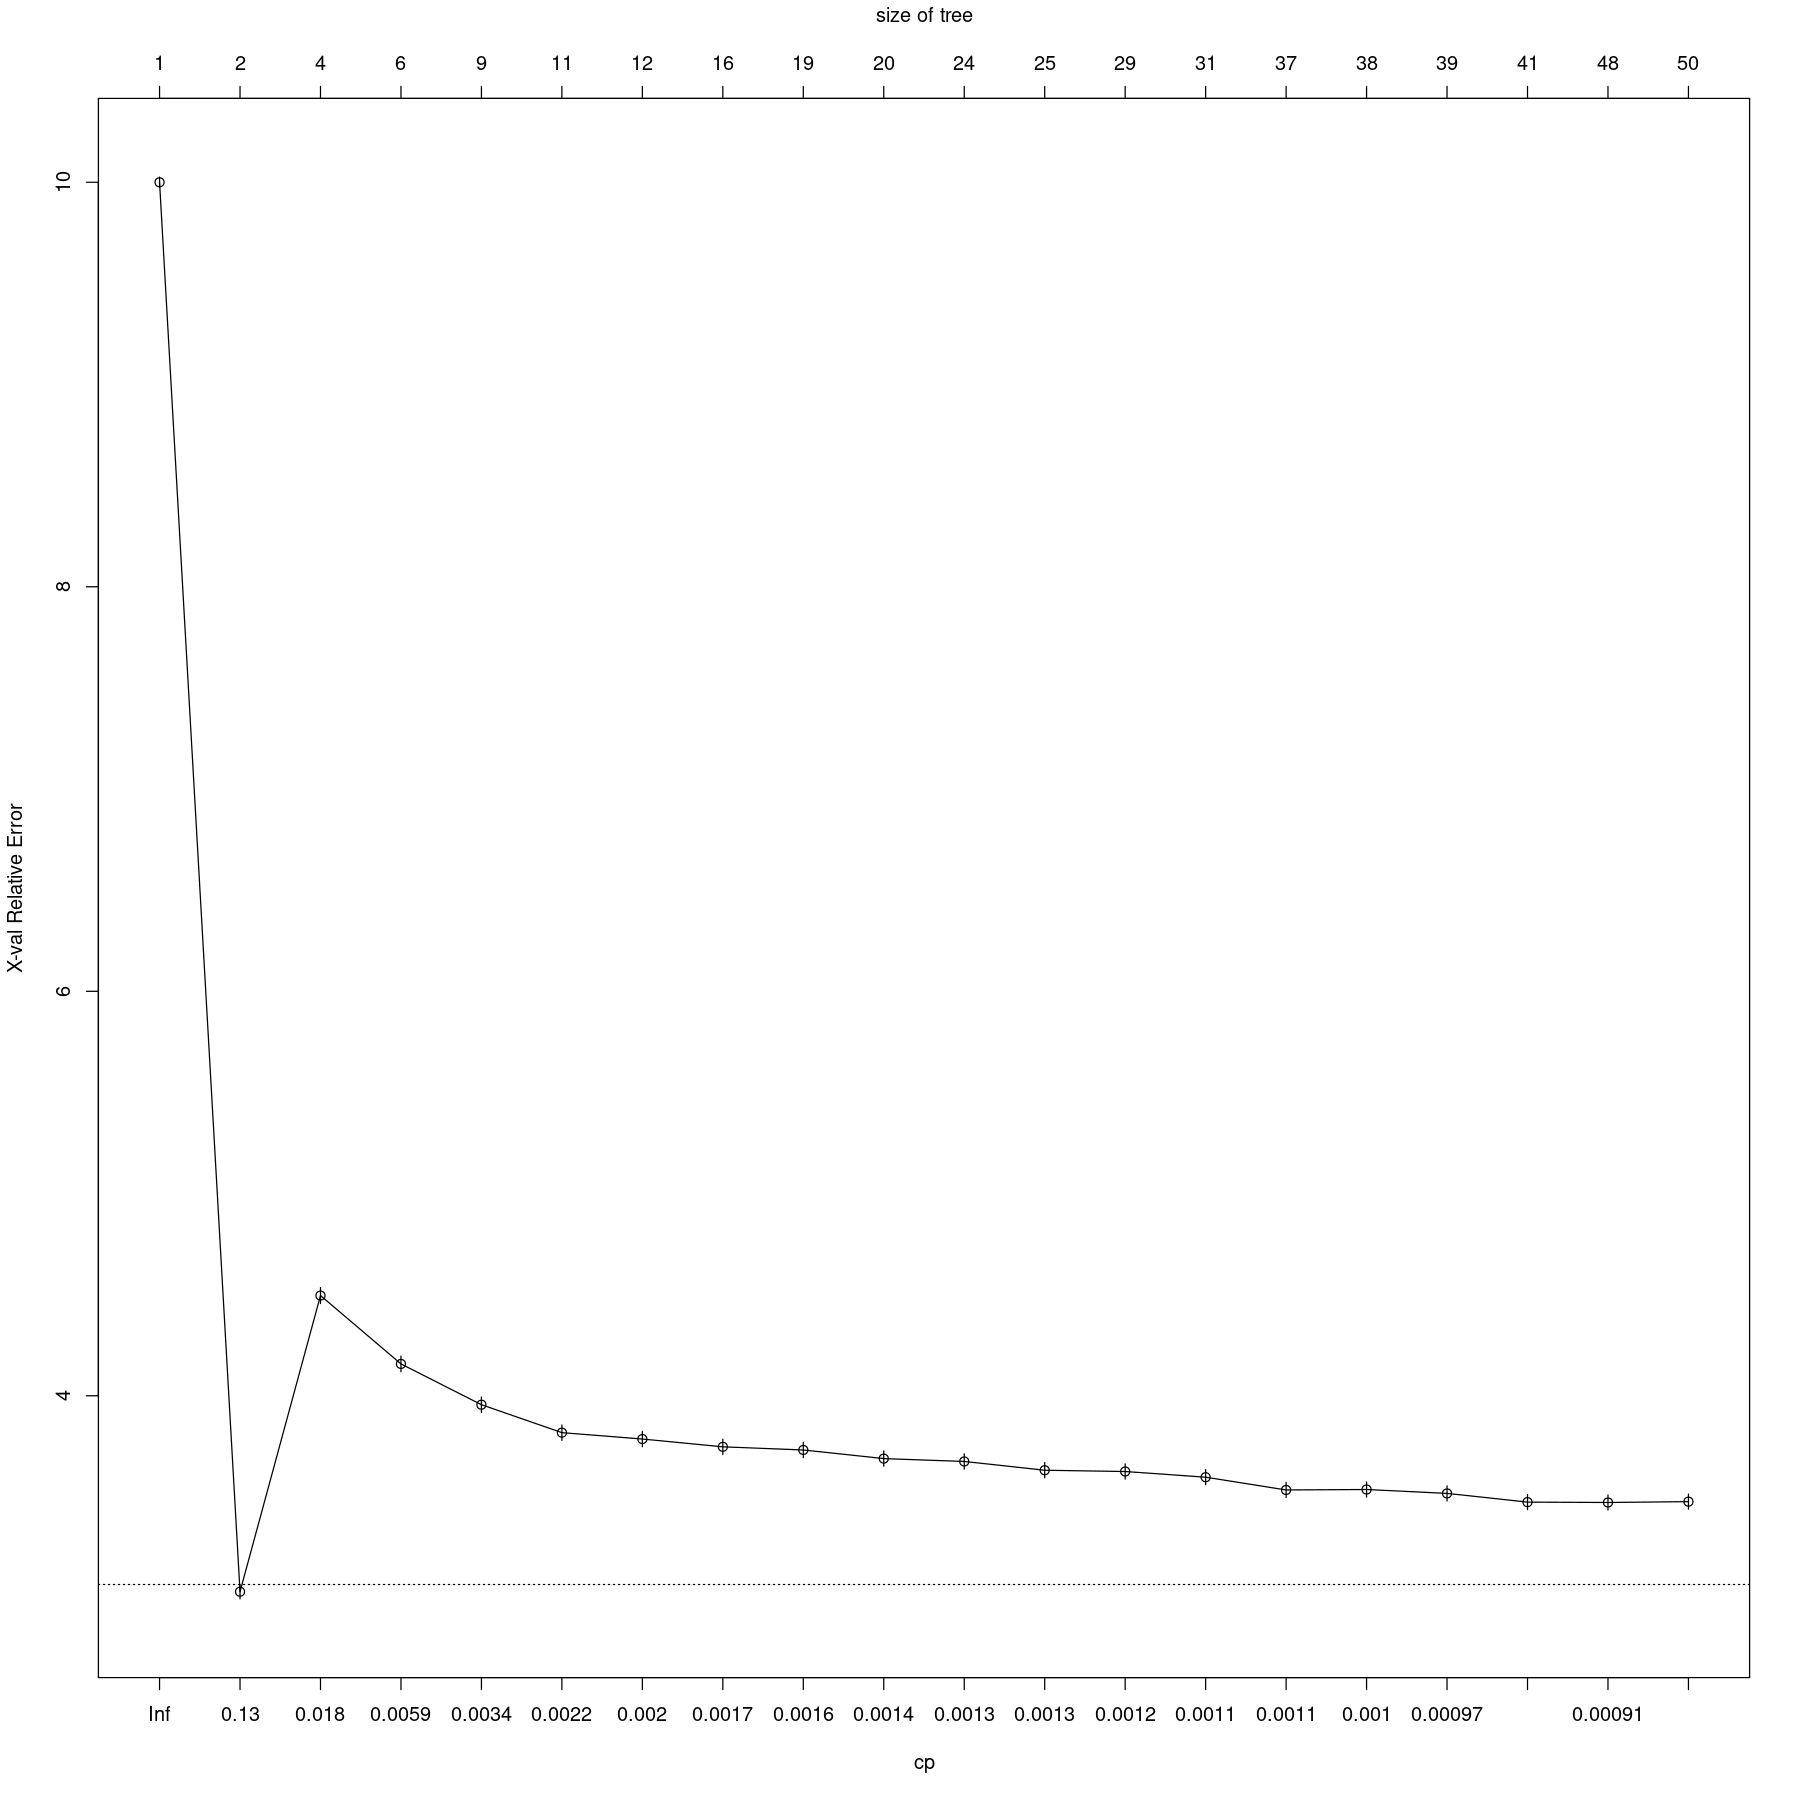

In [41]:
printcp(model_narnia_tree)
plotcp(model_narnia_tree)

The complexity parameter (CP) analysis revealed that decreasing the CP is associated with improved classification accuracy in both the training and cross-validation datasets. As the CP is reduced, the decision tree becomes more complex, leading to a decrease in the training error but an increased risk of overfitting. 

Specifically, the lowest CP that continued to show improvement was 0.00085, where the classification error reached approximately 0.48940. This value represents a balance between more precise fitting and overfitting control, suggesting that a CP of 0.00085 might be optimal for our model.

# 6. Prediction and Model Evaluation

In this section, we'll evaluate how well our predictive models work by checking their accuracy in predicting loan defaults. We’ll use the test set to make predictions and compare them to the actual outcomes. We’ll look at key metrics to see how each model performs. We'll also examine the confusion matrix to understand the number of true positives, false positives, true negatives, and false negatives. 

Here, we selected an observation from the test set to analyze and evaluate the model’s prediction.

In [42]:
# Test set observation
Jedi_Bob <- as.data.frame(test[1,])
Jedi_Bob

,l_status,l_amnt,int,grade,emp_len,home,income,age,sex,region
,<fct>,<int>,<dbl>,<chr>,<int>,<chr>,<dbl>,<int>,<int>,<chr>
1,0,5000,10.65,B,10,RENT,24000,33,0,E


### 6.1 Prediction of the Loan Status

In the evaluation of Jedi_Bob's loan status prediction, we assessed the performance of two logistic regression models:

- **Model Topz** predicted a very low probability of default at approximately \(1.38 \times 10^{-8}\).
- **Model All** also predicted a similarly low probability of default at approximately \(1.36 \times 10^{-8}\).

These results indicate that both models assess Jedi_Bob as having an extremely low likelihood of default. This evaluation focuses solely on the two logistic regression models and highlights their predictions for the selected test observation.

In [43]:
model_ALL <- predict(model_all, newdata = Jedi_Bob, type = "response")
model_TOPZ <- predict(model_topz, newdata = Jedi_Bob, type = "response")
# Collect all.
pred_Jedi <- rbind("model_topz" = model_TOPZ, 
                     "model_all" = model_ALL)
# Prepare a table.
colnames(pred_Jedi) <- "Loan status predictions for Jedi_Bob."
pred_Jedi

,Loan status predictions for Jedi_Bob.
model_topz,1.377954e-08
model_all,1.357995e-08


The range of predicted default probabilities is wider for both logistic regression models, with Model Topz showing a slightly lower AIC compared to Model All. This suggests that Model Topz offers a more varied prediction of default probabilities, potentially capturing a broader range of risk levels.

In [44]:
pred_logi_mt <- predict(model_topz, newdata = test, type = "response")
pred_logi_mu <- predict(model_all, newdata = test, type = "response")
pred_logi_mi <- predict(model_narnia_tree, newdata = test, type = "prob")

pred_range <- rbind("model_topz" = range(pred_logi_mt),
                    "model_all" = range(pred_logi_mu))
# rbind AIC line
aic <- rbind(model_topz$aic, model_all$aic, model_narnia_tree$aic)
# table
pred_range <- cbind(pred_range, aic)
colnames(pred_range) <- c("min(l_status)", "max(l_status)", "AIC")
pred_range

#This table shows the minimum and maximum default probabilities. From 0% to 100%, indicates better performance in capturing the variability of default risk.

,min(l_status),max(l_status),AIC
model_topz,2.220327e-09,0.8538863,10753.03
model_all,1.422469e-09,0.8544424,10763.67


### 6.2 Comparison plot

This code merges predictions from different models into a data frame and reshapes it for comparison plotting.

In [45]:
# To create a comparison plot
pred_logi <- data.frame(cbind(pred_logi_mi, pred_logi_mt,
                                  pred_logi_mi))
pred_logi <- gather(pred_logi, key = "model",  value = "pred")

Then, we created a density plot to compare the performance of different models on the test set.

This plot visually compares the distribution of default predictions across different models, helping to assess their performance.

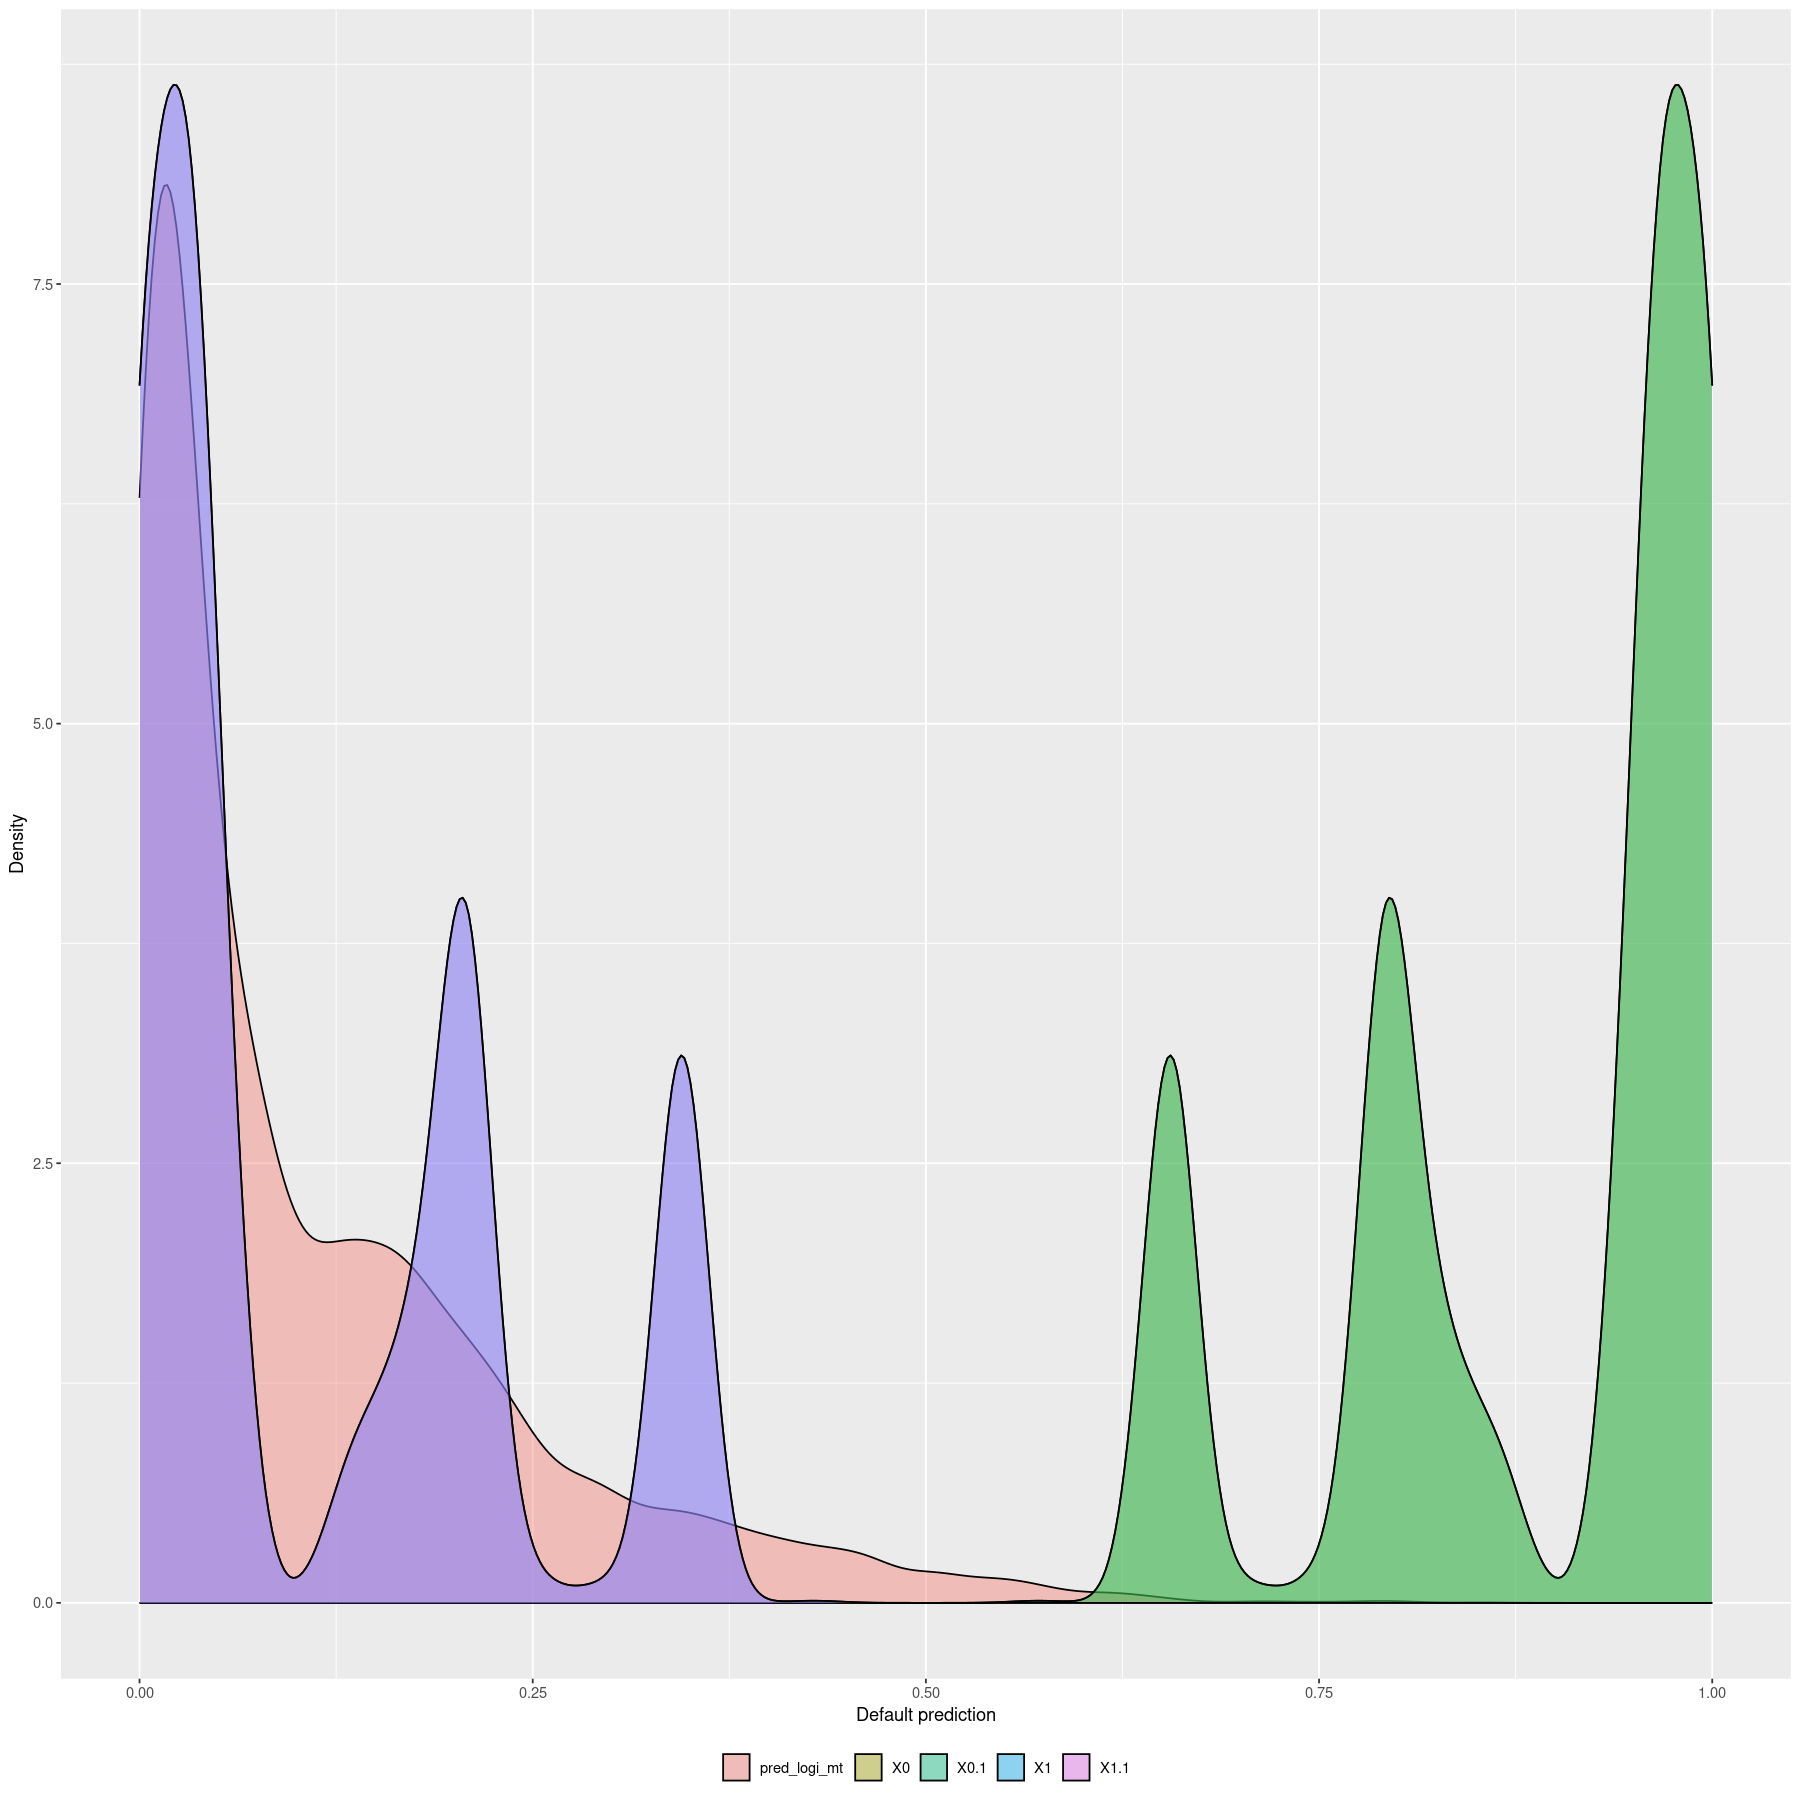

In [46]:
# Plot comparing the performance of the models on the test set
options(repr.plot.width = 15, repr.plot.height = 15)  # Adjust the width and height as needed

ggplot(pred_logi[pred_logi$model != "" ,], 
       aes(x = pred, fill = model)) + 
  geom_density(alpha = 0.4) +
  labs(y = "Density", x = "Default prediction") +
  theme(legend.position = "bottom", legend.title = element_blank())

This box plot provides a clear comparison of the distribution of default predictions among different models, highlighting variations in their prediction ranges and central tendencies.

In [ ]:

# Generate ROC curves
ROC_logi_full <- roc(test$loan_st, pred_logi_mi)
ROC_narnia_tree <- roc(test$loan_st, pred_logi_mu)

# Draw the ROCs on one plot
plot(ROC_logi_full, col = "red")
lines(ROC_narnia_tree, col = "blue")

ERROR: Error in roc.default(test$loan_st, pred_logi_mi): No valid data provided.


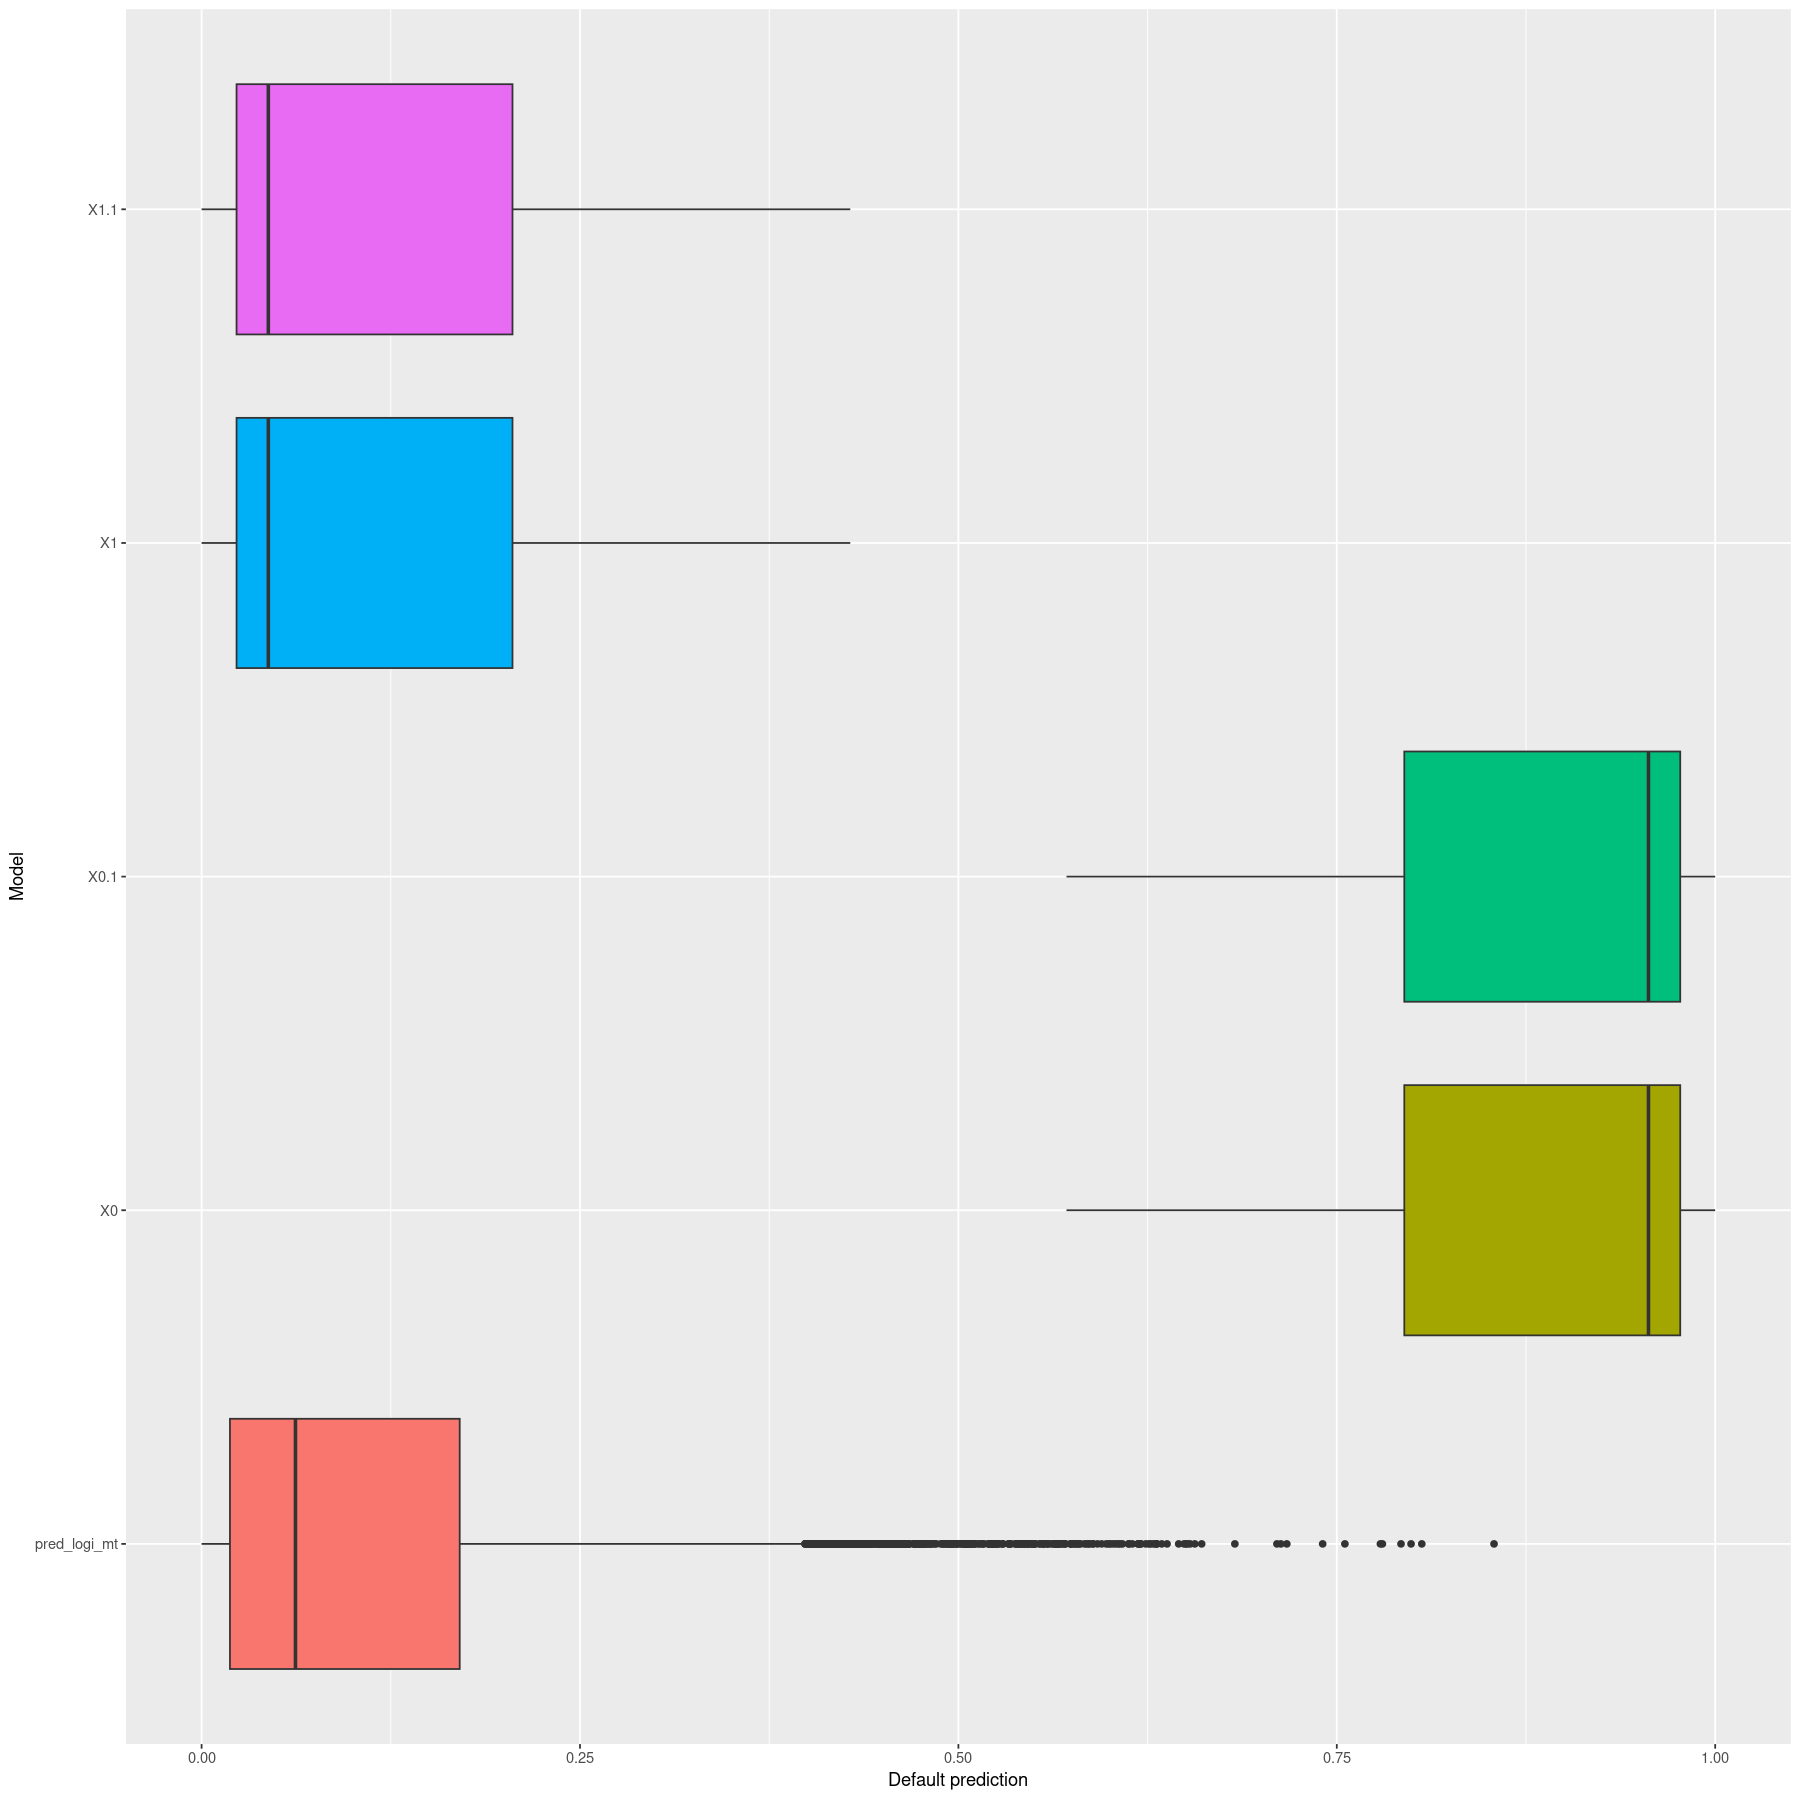

In [22]:
# boxplots for the 3 models
ggplot(pred_logi, aes(x = pred, y = model, fill = model)) + 
  geom_boxplot() +
  labs(y = "Model", x = "Default prediction") +
  theme(legend.position = "none", legend.title = element_blank())

### **6.3 Cutoff Definition**

This line sets a cutoff threshold of 0.2 (or 20%). We used it to decide whether a loan is predicted to default or not based on the model’s probability predictions.

In [23]:
# Cutoff definition. 20%
################################################################
cutoff_tree <- 0.2
predicted_defaults <- pred_logi_mi[, "1"] >= cutoff_tree

### 6.4 Default Filtering

Here, we created a new dataframe, defaults_tree_df, to analyze the prediction results of the decision tree model. Specifically, we filtered the observations from the test set (test) where the model did not predict a default (predictions with FALSE) but were actually defaults (test$l_status == 1). This allowed us to identify false negatives, which are loans that were incorrectly labeled as non-default by the model.

In [24]:
defaults_tree_df <- data.frame(predicted_defaults, test$l_status) |>
						filter(predicted_defaults == "FALSE") |>
							filter(test.l_status == 1)
defaults_tree_df

,predicted_defaults,test.l_status
,<lgl>,<fct>
18,FALSE,1
37,FALSE,1
126,FALSE,1
169,FALSE,1
177,FALSE,1
258,FALSE,1
265,FALSE,1
520,FALSE,1
547,FALSE,1


We then calculated the predictions using the same model but with a new cutoff value.

In [25]:
# Calculate the predictions with the same model and new cutoff.
################################################################
pred_full_20 <- ifelse(pred_logi_mi > cutoff_tree, 1, 0)


### 6.5 Cutoff Definition for Model Topz

The cutoff value of approximately 0.1987 for the model_topz represents the threshold used to classify loans as defaults (1) or non-defaults (0). This threshold is set at the 80th percentile of the predicted probabilities, meaning that it captures the top 20% of predictions with the highest probability of default. By using this cutoff, we wanted to ensure that only loans predicted with a probability greater than 0.1987 were classified as defaults. 

In [26]:
# Cutoff of modelo topz
cutoff <- quantile(pred_logi_mt, 0.8)
cutoff

80% 
0.1987236

### 6.6 Evaluation of Performance

We created a comparative table to evaluate the performance of the model with the cutoff value of 0.20. This table displays the actual loan status (test$l_status), the predicted defaults using the new cutoff (pred_full_20), and whether the model's prediction was accurate ("Did the model succeed?").

In [27]:
# Comparative table in detail.
real_pred_20 <- cbind.data.frame(test$l_status, pred_full_20,
                     "Did the model succeed?" = test$l_status==pred_full_20)
# Show some values.
real_pred_20[131:160,]

,test$l_status,0,1,Did the model succeed?.0,Did the model succeed?.1
,<fct>,<dbl>,<dbl>,<lgl>,<lgl>
398,0,1,1,FALSE,FALSE
399,1,1,1,TRUE,TRUE
404,0,1,1,FALSE,FALSE
414,0,1,0,FALSE,TRUE
417,1,1,1,TRUE,TRUE
419,0,1,1,FALSE,FALSE
420,0,1,1,FALSE,FALSE
425,1,1,1,TRUE,TRUE
431,0,1,1,FALSE,FALSE


Then, we used a confusion matrix to evaluate the performance of our logistic regression model with the cutoff value. The confusion matrix helps us assess how accurately our model predicts loan defaults by comparing the actual loan statuses with the predicted ones. 

We calculate the predictions using the updated cutoff value of 0.20 for the model_topz, this matrix provided us a detailed breakdown of true positives, true negatives, false positives, and false negatives, allowing us to evaluate the model's classification performance.

In [28]:
# Show results in a confusion matrix.
pred_full2_20 <- ifelse(pred_logi_mt > cutoff, 1, 0)
CrossTable(test$l_status, pred_full2_20, prop.r = TRUE,
           prop.c = FALSE, prop.t = FALSE, prop.chisq = FALSE)


 
   Cell Contents
|-------------------------|
|                       N |
|           N / Row Total |
|-------------------------|

 
Total Observations in Table:  9695 

 
              | pred_full2_20 
test$l_status |         0 |         1 | Row Total | 
--------------|-----------|-----------|-----------|
            0 |      7311 |      1324 |      8635 | 
              |     0.847 |     0.153 |     0.891 | 
--------------|-----------|-----------|-----------|
            1 |       445 |       615 |      1060 | 
              |     0.420 |     0.580 |     0.109 | 
--------------|-----------|-----------|-----------|
 Column Total |      7756 |      1939 |      9695 | 
--------------|-----------|-----------|-----------|

 


The matrix shows that the model correctly predicted 7311 cases of no default and 615 cases of default. This information helped us assess the model's performance by identifying how well it distinguishes between default and non-default cases.

# 7. Bad Rate Calculation

To further assess model performance, we calculated the bad rate for the decision tree model. This represents the proportion of actual defaults among the loans that the model predicted as non-defaults.

### 7.1 Tree Model

In [29]:
accepted_loans <- real_pred_20[pred_full2_20 == 0, 1]

#bad_rate_tree <- mean(predicted_defaults)  
bad_rate_tree2 <- sum(defaults_tree_df == 1)/length(accepted_loans)
bad_rate_tree2 

[1] 0.04177411

The calculated bad rate of approximately 4.18% indicates the proportion of loans that were incorrectly predicted as non-defaults by the decision tree model with the cutoff.

This tells us that the model is more effective at minimizing defaults among accepted loans. This highlights Model Narnia's conservative approach, which, while rejecting more loans overall, does a better job of avoiding defaults among those it does approve.

### 7.2 Logistic Model

In [30]:
# We accept loans that the model predicts a no-default (0).
# In "accepted_loans" we know whether the accepted loans are in fact
# default or no-default.

# The code above says: if we accept the application, tell me what happened.
head(accepted_loans, 10)

[1] 0 0 1 0 0 0 0 0 0 1
Levels: 0 1

In [31]:
# bad_rate is the proportion of accepted loans that are in fact default.
bad_rate <- sum(accepted_loans == 1)/length(accepted_loans)
bad_rate

[1] 0.05737494

This result means that about 5.74% of the loans that were approved by Model Topz have defaulted. While this is a relatively low percentage, it indicates that there is still a risk associated with the accepted loans.

### 7.3 Acceptance Tables

After calculating the bad rate, we created the acceptance tables for Model Narnia and Topz (our best logistic model) to further evaluate their performance. This table provided insights into the distribution of predicted loan statuses based on the model's cutoff values.

In [32]:
# Acceptance Table for Model Narnia
# Accepted.
accept_20 <- sum(pred_full_20 == 0)
# Rejected.
reject_20 <- sum(pred_full_20 == 1)
data.frame("total" = length(pred_full_20), accept_20, reject_20)

total,accept_20,reject_20
<int>,<int>,<int>
19390,6830,12560


In [33]:
# Acceptance Table for Model Topz
# Accepted.
accept2_20 <- sum(pred_full2_20 == 0)
# Rejected.
reject2_20 <- sum(pred_full2_20 == 1)
data.frame("total" = length(pred_full2_20), accept2_20, reject2_20)

total,accept2_20,reject2_20
<int>,<int>,<int>
9695,7756,1939


With this results, Model Topz demonstrates a higher acceptance rate, approving more loans and rejecting fewer. This suggest that Model Topz is more lenient in its predictions.

On the other hand, Model Narnia results in a higher rejection rate. This conservative approach, while leading to fewer false positives. 

To summarize it: 

Model Narnia is better from a default prediction perspective, as evidenced by its lower bad rate. It provides more accurate predictions regarding defaults, making it a preferable choice for minimizing financial risk related to incorrect default predictions.

However, Model Topz's higher acceptance rate might be beneficial if the goal is to approve more loans while accepting a slightly higher risk. The trade-off between these models lies in balancing the accuracy of default predictions with the impact on loan approval rates.

# 8. Conclusions

In [34]:
print(paste("We have a bad rate for the Tree Model of:", round((bad_rate_tree2)*100,3), "%"))

[1] "We have a bad rate for the Tree Model of: 4.177 %"


In [35]:
print(paste("We have a bad rate for the Topz Model of:", round((bad_rate)*100,3), "%"))

[1] "We have a bad rate for the Topz Model of: 5.737 %"


- Bad rate to beat: 5.763%
- Bad rate for the All Model: 5.763%
- Bad rate for the Topz Model: 5.737%
- Bad rate for the Tree Model: **4.177%**


In comparing Model Topz and Model Narnia = Tree Model, we observe distinct differences in their performance and risk profiles:

1. **Model Topz** has a higher acceptance rate, approving more loans and rejecting fewer. This means that the model is more lenient, allowing for a broader range of applicants to receive loans. However, this leniency comes at the cost of a higher bad rate of **5.74%**, meaning a greater proportion of the accepted loans end up defaulting.

2. **Model Narnia**, on the other hand, adopts a more conservative approach with a higher rejection rate. This cautious strategy results in a lower bad rate of **4.18%**, indicating that fewer of the accepted loans default. While this approach reduces the likelihood of defaults, it also means that more applicants are denied loans, potentially excluding some who might have successfully repaid.

3. The trade-off between the two models is clear: Model Topz provides a more inclusive approach with higher loan approvals but at a slightly increased risk of defaults. In contrast, Model Narnia prioritizes minimizing defaults, even if it means rejecting more applicants.

4. The choice between these models depends on the risk tolerance and business strategy. If we are aiming to minimize losses and defaults, **Model Narnia** presents a better option. Conversely, if you are willing to accept a higher default rate in exchange for higher loan approval rates might prefer **Model Topz**.

Overall, as a team, we agree that Model Narnia demonstrates better performance in terms of reducing defaults, making it a more suitable option for conservative risk management. On the other hand, Model Topz might be more appropriate for institutions focused on growth through higher loan issuance, despite the increased risk of defaults.

## We hereby affirm that we have done this activity with academic integrity
## -Team Narnia